# Example: Bidirectional LSTM autoencoder on HDD failure data

This notebook shows a compact local HDD failure example using `BidirectionalLSTMSeq2OneAutoencoder` inside `EnergyFaultDetector`.

Structure:
1. Import the package and helper libraries
2. Load a compact HDD subset derived from Backblaze SMART data FOR HDD 
3. Build the bidirectional sequence model configuration
4. Train on the normal operating window
5. Predict anomaly scores and visualize the pre-failure behaviour

In [1]:
from __future__ import annotations

import logging
import warnings
from pathlib import Path

warnings.filterwarnings('ignore', message='.*urllib3.*doesn\'t match a supported version.*')
warnings.filterwarnings('ignore', message='.*IProgress not found.*')

notebook_dir = Path.cwd().resolve()
repo_candidates = [notebook_dir, *notebook_dir.parents]
drive_root = Path(notebook_dir.anchor)
repo_candidates.extend(child / 'EnergyFaultDetector' for child in drive_root.iterdir() if child.is_dir())

seen = []
for candidate in repo_candidates:
    candidate = candidate.resolve()
    if candidate not in seen:
        seen.append(candidate)

repo_root = next((p for p in seen if (p / 'energy_fault_detector').exists()), None)
if repo_root is None:
    raise RuntimeError('Could not find the EnergyFaultDetector repository. Run the notebook locally with access to the project files.')

data_candidates = [
    notebook_dir / 'hdd_bidirectional_sample.csv',
    repo_root / 'notebooks' / 'HDD Failure' / 'hdd_bidirectional_sample.csv',
]
data_path = next((p for p in data_candidates if p.exists()), None)
if data_path is None:
    raise FileNotFoundError('Could not find hdd_bidirectional_sample.csv next to the notebook or inside notebooks/HDD Failure.')

import os
import sys
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '2')
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from energy_fault_detector import Config, FaultDetector

logging.getLogger('energy_fault_detector').setLevel(logging.WARNING)
logging.getLogger('tensorflow').setLevel(logging.ERROR)
tf.get_logger().setLevel('ERROR')
np.random.seed(7)
tf.keras.utils.set_random_seed(7)

print(f'Using repository root: {repo_root}')
print(f'Using data file: {data_path}')


Using repository root: D:\germanpooj\EnergyFaultDetector
Using data file: D:\EnergyFaultDetector_personal_archive_20260330\personal_notebooks\Bidirectional_LSTM_HDD_Backblaze_Example\hdd_bidirectional_sample.csv


## Load a compact HDD example

As an Example, we use a small extracted subset for one real failing `ST4000DM000` disk (`S301KWJY`).

In [2]:
SERIAL_NUMBER = 'S301KWJY'
FAILURE_DATE = pd.Timestamp('2021-09-07')
FEATURES = [
    'smart_4_raw', 'smart_7_raw', 'smart_9_raw',
    'smart_190_raw', 'smart_193_raw', 'smart_194_raw',
    'smart_240_raw', 'smart_241_raw', 'smart_242_raw',
]

hdd_df = pd.read_csv(data_path, parse_dates=['date']).sort_values('date').reset_index(drop=True)
hdd_df[['date', 'serial_number', 'model', 'failure'] + FEATURES[:4]].head()

,date,serial_number,model,failure,smart_4_raw,smart_7_raw,smart_9_raw,smart_190_raw
0,2021-07-25,S301KWJY,ST4000DM000,0,19.0,983881959.0,50295.0,27.0
1,2021-07-26,S301KWJY,ST4000DM000,0,19.0,986659063.0,50319.0,28.0
2,2021-07-27,S301KWJY,ST4000DM000,0,19.0,988333279.0,50343.0,27.0
3,2021-07-28,S301KWJY,ST4000DM000,0,19.0,990171186.0,50367.0,27.0
4,2021-07-29,S301KWJY,ST4000DM000,0,19.0,991611526.0,50391.0,28.0


In [3]:
sample_overview = pd.Series({
    'rows': len(hdd_df),
    'first_date': hdd_df['date'].min().date(),
    'last_date': hdd_df['date'].max().date(),
    'failed_disk': hdd_df['serial_number'].iat[0],
    'model': hdd_df['model'].iat[0],
    'failure_rows': int(hdd_df['failure'].sum()),
})
sample_overview

rows                     45
first_date       2021-07-25
last_date        2021-09-07
failed_disk        S301KWJY
model           ST4000DM000
failure_rows              1
dtype: object

## Prepare sensor data and the normal training window

The model reconstructs the last timestep of each 7-day window. We train on the early normal operating period and then predict on the full history.

In [4]:
hdd_df = hdd_df.set_index('date').sort_index()
sensor_data = hdd_df[FEATURES].astype(float)
train_end = pd.Timestamp('2021-08-24')
normal_index = pd.Series(sensor_data.index <= train_end, index=sensor_data.index)

pd.Series({
    'training_rows': int(normal_index.sum()),
    'prediction_rows': int(len(sensor_data)),
    'train_start': sensor_data.index.min().date(),
    'train_end': train_end.date(),
    'failure_date': FAILURE_DATE.date(),
})

training_rows              31
prediction_rows            45
train_start        2021-07-25
train_end          2021-08-24
failure_date       2021-09-07
dtype: object

## Configure and train the bidirectional sequence model

This configuration follows the sequence-model style already used in the package.

In [5]:
config_dict = {
    'train': {
        'data_preprocessor': {},
        'autoencoder': {
            'name': 'BidirectionalLSTMSeq2OneAutoencoder',
            'verbose': 0,
            'params': {
                'sequence_builder': {
                    'sequence_length': 7,
                    'stride': 1,
                    'ts_freq': '1D',
                    'pad_incomplete': False,
                    'pad_value': 0.0,
                },
                'layers': [16, 8],
                'dropout_rate': 0.0,
                'regularization': 0.001,
                'stateful': False,
                'merge_mode': 'sum',
                'learning_rate': 0.001,
                'batch_size': 4,
                'epochs': 40,
                'loss_name': 'mean_squared_error',
                'metrics': ['mean_absolute_error'],
                'early_stopping': False,
                'noise': 0.0,
            },
        },
        'anomaly_score': {
            'name': 'rmse',
            'params': {'standardize': True},
        },
        'threshold_selector': {
            'name': 'quantile',
            'params': {'quantile': 0.97},
        },
        'data_splitter': {
            'type': 'train_test_split',
            'validation_split': 0.2,
            'shuffle': False,
        },
    }
}

fd = FaultDetector(config=Config(config_dict=config_dict))
model_meta = fd.fit(sensor_data=sensor_data, normal_index=normal_index, save_models=False)
print(f'Model trained successfully ({type(model_meta).__name__}).')

Model trained successfully (ModelMetadata).


## Predict anomaly scores

In [6]:
results = fd.predict(sensor_data=sensor_data)
score_df = pd.DataFrame({
    'anomaly_score': results.anomaly_score,
    'predicted_anomaly': results.predicted_anomalies.astype(int),
}).join(hdd_df[['failure']])
score_df['days_to_failure'] = (FAILURE_DATE - score_df.index).days
score_df.tail(15)

,anomaly_score,predicted_anomaly,failure,days_to_failure
2021-08-24,1.660300,1,0,14
2021-08-25,1.874786,1,0,13
2021-08-26,4.291953,1,0,12
2021-08-27,3.496014,1,0,11
2021-08-28,3.692369,1,0,10
2021-08-29,4.127965,1,0,9
2021-08-30,5.752882,1,0,8
2021-08-31,6.201900,1,0,7
2021-09-01,6.649876,1,0,6
2021-09-02,6.197617,1,0,5


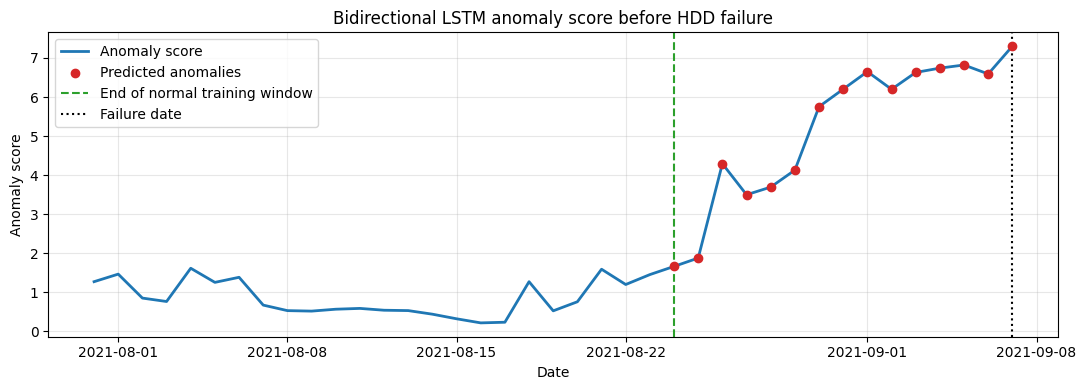

In [7]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(score_df.index, score_df['anomaly_score'], label='Anomaly score', color='tab:blue', linewidth=2)
anomaly_points = score_df[score_df['predicted_anomaly'] == 1]
ax.scatter(anomaly_points.index, anomaly_points['anomaly_score'], color='tab:red', label='Predicted anomalies', zorder=3)
ax.axvline(train_end, color='tab:green', linestyle='--', label='End of normal training window')
ax.axvline(FAILURE_DATE, color='black', linestyle=':', label='Failure date')
ax.set_title('Bidirectional LSTM anomaly score before HDD failure')
ax.set_ylabel('Anomaly score')
ax.set_xlabel('Date')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Compare normal and pre-failure score levels

In [8]:
summary = pd.Series({
    'mean_score_training_window': score_df.loc[score_df.index <= train_end, 'anomaly_score'].mean(),
    'mean_score_pre_failure_window': score_df.loc[score_df.index > train_end, 'anomaly_score'].mean(),
    'predicted_anomalies_pre_failure': int(score_df.loc[score_df.index > train_end, 'predicted_anomaly'].sum()),
    'predicted_anomalies_total': int(score_df['predicted_anomaly'].sum()),
})
summary

mean_score_training_window          0.886072
mean_score_pre_failure_window       5.454938
predicted_anomalies_pre_failure    14.000000
predicted_anomalies_total          15.000000
dtype: float64